# 15-plots in plotly

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
# import dataset 
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

# 1. scatter plot

In [7]:
fig1 = px.scatter(df, x='sepal_length', y='sepal_width', color='species')
fig1.show()
# save the plot
fig1.write_image('fig1.png',scale=3)

# 2.line plot

In [14]:
df_line = df.sort_values(by=['sepal_length'])


fig2 = px.line(df_line, x='sepal_length', y='sepal_width', color='species')
fig2.show()
# save the plot
fig2.write_image('fig2.png',scale=3)

# 3. bar plot

In [20]:
df_bar = df.groupby(['species']).mean().reset_index()
df_bar.head()

,species,sepal_length,sepal_width,petal_length,petal_width
0,setosa,5.006,3.428,1.462,0.246
1,versicolor,5.936,2.770,4.260,1.326
2,virginica,6.588,2.974,5.552,2.026


In [24]:
# group values based on means
df_bar = df.groupby(['species']).mean().reset_index()

fig3 = px.bar(df_bar, x='species', y='sepal_width')
fig3.show()
# save the plot
fig3.write_image('fig3.png',scale=3)


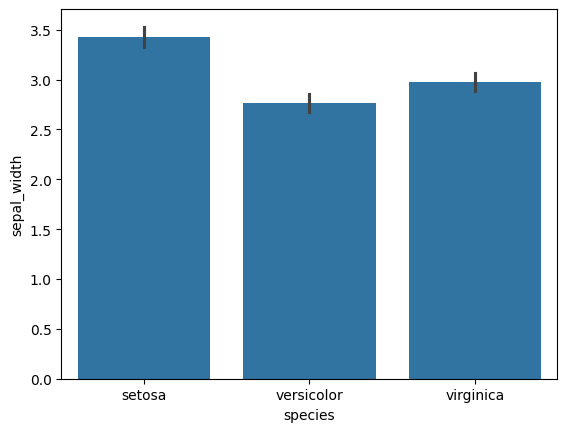

In [21]:
# seaborn dose not need to make mean groups

sns.barplot(x='species', y='sepal_width', data=df)
plt.show()

In [26]:
fig4 = px.box(df, x='species', y='sepal_width', color='species')
fig4.show()
# save the plot
fig4.write_image('fig4.png',scale=3)

In [27]:
# violon plot 

fig5 = px.violin(df, x='species', y='sepal_width', color='species')
fig5.show()
# save the plot
fig5.write_image('fig5.png',scale=3)    

In [28]:
# histogram 

fig6 = px.histogram(df, x='sepal_width', color='species')
fig6.show()
# save the plot
fig6.write_image('fig6.png',scale=3)

In [32]:
df_pie = df['species'].value_counts().reset_index()
df_pie.columns = ['species', 'count']
df_pie.head()

,species,count
0,setosa,50
1,versicolor,50
2,virginica,50


In [36]:
# 7 pie chart 

fig7 = px.pie(df_pie, values='count', names='species')
fig7.show()
# save the plot
fig7.write_image('fig7.png',scale=3)

In [40]:
# 8 scatter 3d plot
fig8 = px.scatter_3d(df, x='sepal_length', y='sepal_width', z='petal_length', color='species')
fig8.show()
# save the plot
fig8.write_html('fig8.html')

In [43]:
# 9 area chart 
df_area = df.sort_values(by=['sepal_length'])

fig9 = px.area(df_area, x='sepal_width', y='sepal_length', color='species')
fig9.show()
# save the plot
fig9.write_image('fig9.png',scale=3)

In [44]:
# 10 bubble chart

fig10 = px.scatter(df, x='sepal_length', y='sepal_width', size='petal_length', color='species')
fig10.show()
# save the plot
fig10.write_image('fig10.png',scale=3)

In [53]:
# 11 sunburst chart 
df_sunburst = df.groupby(['species', 'petal_width']).size().reset_index(name='counts')


fig11 = px.sunburst(df_sunburst, path=['species', 'petal_width'], values='counts')
fig11.show()

# save the plot
fig11.write_html('fig11.html')

In [62]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'species_id'],
      dtype='object')

In [63]:
# 12 parallel coordinates chart
df['species_id'] = df['species'].astype('category').cat.codes

fig12 = px.parallel_coordinates(df, color='species_id', labels={'species_id':'species'}, color_continuous_scale=px.colors.sequential.Plasma)
fig12.show()
# save the plot
fig12.write_image('fig12.png',scale=3)

In [64]:
# 13 Density contour plot

fig13 = px.density_contour(df, x='sepal_length', y='sepal_width', color='species')
fig13.show()
# save the plot
fig13.write_image('fig13.png',scale=3)

In [65]:
# 14 ternary plot

fig14 = px.scatter_ternary(df, a='sepal_length', b='sepal_width', c='petal_length', color='species')
fig14.show()
# save the plot
fig14.write_image('fig14.png',scale=3)

In [66]:
# 15 plar chart 

df_redar = df.groupby(['species']).mean().reset_index()

fig15 = px.line_polar(df_redar, r='sepal_length', theta='species', line_close=True)
fig15.show()
# save the plot
fig15.write_image('fig15.png',scale=3)